# Camera Pseudo-Footprints — `camera_segmentation` Demonstration

This notebook demonstrates
[`libera_utils.footprint_matching.camera_segmentation`](../libera_utils/footprint_matching/camera_segmentation.py)
— the module that turns an **L1B Daily Camera** image into radiometer-sized
**pseudo-footprints** for the camera-timescale FMATCH products
(`FMATCH-CAM-CAMTIME`, `FMATCH-IMAGER-CAMTIME`).

### Why this step exists

The Libera radiometer measures one broadband **footprint** at a time along its scan.
The wide-field **camera**, by contrast, delivers a whole *image*: for each
`CAMERA_TIME` there is a `CAMERA_PIXEL_COUNT_X` × `CAMERA_PIXEL_COUNT_Y` grid of
individually geolocated pixels. That per-pixel grid is *far finer* than a radiometer footprint.

Before the footprint-matching machinery can treat camera data "as if" it were a set
of radiometer footprints, each image must be **segmented into pseudo-footprints**: a
*pseudo-footprint* is a contiguous block of camera pixels sized so its ground extent
is comparable to a real radiometer footprint. Each block then becomes **one record**
on the `CAMERA_TIME` axis of the FMATCH-CAM-CAMTIME product — exactly as a radiometer
footprint is one record on the `RADIOMETER_TIME` axis of FMATCH-CAM.

### What the module computes for each pseudo-footprint

1. A geographic **bounding box** built *only from the four corner pixels* of the block.
   The camera pixels are already geolocated (unlike the radiometer, which needs the
   viewing-geometry ray-trace in [`geometry.py`](../libera_utils/footprint_matching/geometry.py)),
   so the enclosing box is just the lat/lon envelope of the corners — no need to
   inspect every interior pixel. Pole/dateline handling is delegated to the *same*
   assembler the radiometer path uses (`bounding_box_from_points`), so both products
   get identical edge-case behavior.
2. The per-footprint scalar geolocation/geometry (lat, lon, altitude, solar/viewing
   zenith and relative azimuth angles) taken from the block's **center pixel** — the
   pseudo-footprint's stand-in for the radiometer boresight.

### Roadmap of this notebook

| Section | What it shows |
| --- | --- |
| 1 | Build a synthetic L1B camera image (crosses the Earth's limb) |
| 2 | Sizing a block: FOV → target footprint diameter, and ground-sampling distance |
| 3 | Tiling the pixel grid into blocks (`_iter_blocks`, `_corner_indices`) |
| 4 | One block → corner bounding box + center pixel (`bounding_box_from_points`) |
| 5 | The off-Earth policy and quality flags |
| 6 | The public entry point `segment_l1b_camera` |
| 7 | Assembling the FMATCH-CAM-CAMTIME product |
| 8 | (Optional) running on a real L1B camera file |

In [64]:
import matplotlib.pyplot as plt
import numpy as np
import xarray as xr
from matplotlib.colors import BoundaryNorm, ListedColormap
from matplotlib.lines import Line2D
from matplotlib.patches import Rectangle

# The module under demonstration, plus the handful of public symbols we use directly.
from libera_utils.footprint_matching import camera_segmentation as seg
from libera_utils.footprint_matching.camera_segmentation import (
    TARGET_FOOTPRINT_DIAMETER_KM,
    CameraFootprintQualityFlag,
    segment_l1b_camera,
)

# Shared building blocks that camera_segmentation reuses from the radiometer path.
from libera_utils.footprint_matching.geometry import (
    L1B_FILL_VALUE,  # -999: the L1B "off-Earth" sentinel
    NOMINAL_ALTITUDE_KM,  # 835 km nominal orbit altitude
    bounding_box_from_points,
)
from libera_utils.footprint_matching.psf import LIBERA_FOV_HALFANGLE_DEG  # 1.0 deg

plt.rcParams["figure.dpi"] = 110

# A consistent colour per outcome, reused across the plots below.
FLAG_COLORS = {
    "clean": "tab:blue",
    "partial": "tab:orange",
    "substituted": "tab:green",
    "dropped": "tab:red",
}

## 1. A synthetic L1B camera image

The key features we want to reproduce with this synthetic data are the ones that
drive the interesting behavior in the segmenter:

- **Geolocated pixels.** Each pixel carries a `Latitude`/`Longitude`. We lay them out
  on a regular lat/lon grid — pixel `[x, y]` sits at `(lat0 + (x−cx)·Δ, lon0 + (y−cy)·Δ)`.
- **The Earth's limb.** A wide-field camera sees *past* the edge of the Earth. Pixels
  that miss the Earth ("space" or calibration views) are stored with the fill sentinel
  `L1B_FILL_VALUE` (`-999`). We model the limb as a disc: pixels beyond a radius from
  the image center are off-Earth. This makes the image corners fill and cuts the limb
  diagonally through the edge blocks.
- **A couple of bad interior pixels.** Two otherwise-valid interior pixels are set to
  fill to demonstrate *center-pixel substitution* (Section 5).
- **Viewing geometry.** Solar zenith varies with latitude and viewing zenith grows
  toward the limb, so the per-footprint center-pixel scalars actually vary.

The dataset uses the exact dimension/variable names from l1b cam data product definition; the module reads those names
from module-level constants (`seg.LATITUDE_NAME`, `seg.PIXEL_X_DIM`, …) so nothing is
hard-coded inline.

In [65]:
def make_synthetic_l1b_camera(
    *,
    nx: int = 45,
    ny: int = 45,
    lat0: float = 10.0,
    lon0: float = 20.0,
    deg_per_pixel: float = 0.05,
    limb_radius_px: float = 24.0,
    bad_pixels: tuple[tuple[int, int], ...] = ((12, 12), (32, 12)),
) -> xr.Dataset:
    """Return a single-image L1B Daily Camera ``xr.Dataset`` that crosses the limb.

    Pixel ``[x, y]`` is placed at ``(lat0 + (x-cx)*deg_per_pixel,
    lon0 + (y-cy)*deg_per_pixel)``. Any pixel farther than ``limb_radius_px`` from the
    image center (plus the explicit ``bad_pixels``) is marked off-Earth with
    ``L1B_FILL_VALUE`` in *every* field, exactly as the real L1B product would.
    """
    cx, cy = nx // 2, ny // 2
    ix = np.arange(nx)[:, None]  # column vector of x (latitude) indices
    iy = np.arange(ny)[None, :]  # row vector of y (longitude) indices

    # Regular lat/lon grid. Broadcasting fills the full (nx, ny) 2-D image.
    lat = np.broadcast_to(lat0 + (ix - cx) * deg_per_pixel, (nx, ny)).astype(float).copy()
    lon = np.broadcast_to(lon0 + (iy - cy) * deg_per_pixel, (nx, ny)).astype(float).copy()

    # Distance (in pixels) from the image center; drives the limb disc and the VZA.
    r_px = np.broadcast_to(np.sqrt((ix - cx) ** 2 + (iy - cy) ** 2), (nx, ny)).astype(float)

    # Plausible geometry: SZA trends with latitude; VZA grows toward the limb.
    sza = 50.0 + (lat - lat0) * 0.8
    vza = 60.0 * (r_px / r_px.max())
    raa = np.full((nx, ny), 120.0)
    alt = np.full((nx, ny), 835_000.0)  # metres, as stored in L1B

    # Everything beyond the limb disc (and the punched-in bad pixels) is off-Earth.
    off_earth = r_px > limb_radius_px
    for bx, by in bad_pixels:
        off_earth[bx, by] = True
    for field in (lat, lon, sza, vza, raa, alt):
        field[off_earth] = L1B_FILL_VALUE

    # (CAMERA_TIME, CAMERA_PIXEL_COUNT_X, CAMERA_PIXEL_COUNT_Y) — one image at t=0.
    dims = (seg.CAMERA_TIME_NAME, seg.PIXEL_X_DIM, seg.PIXEL_Y_DIM)
    times = np.array([np.datetime64("2028-02-12T03:39:45", "ns")])
    return xr.Dataset(
        {
            seg.LATITUDE_NAME: (dims, lat[None]),
            seg.LONGITUDE_NAME: (dims, lon[None]),
            seg.ALTITUDE_NAME: (dims, alt[None]),
            seg.SOLAR_ZENITH_NAME: (dims, sza[None]),
            seg.VIEWING_ZENITH_NAME: (dims, vza[None]),
            seg.RELATIVE_AZIMUTH_NAME: (dims, raa[None]),
        },
        coords={seg.CAMERA_TIME_NAME: times},
    )


ds = make_synthetic_l1b_camera()

# Pull the first (only) image's 2-D grids out for plotting and step-by-step calls.
lat2d = ds[seg.LATITUDE_NAME].values[0]
lon2d = ds[seg.LONGITUDE_NAME].values[0]
vza2d = ds[seg.VIEWING_ZENITH_NAME].values[0]
nx, ny = lat2d.shape

# A pixel is usable only if BOTH lat and lon are valid (neither fill nor non-finite).
# This is the very same test the module applies inside _segment_image.
valid = np.vectorize(seg._is_valid)(lat2d) & np.vectorize(seg._is_valid)(lon2d)
print(f"image: {nx} x {ny} pixels; {valid.sum()} on-Earth ({100 * valid.mean():.0f}%)")

image: 45 x 45 pixels; 1735 on-Earth (86%)


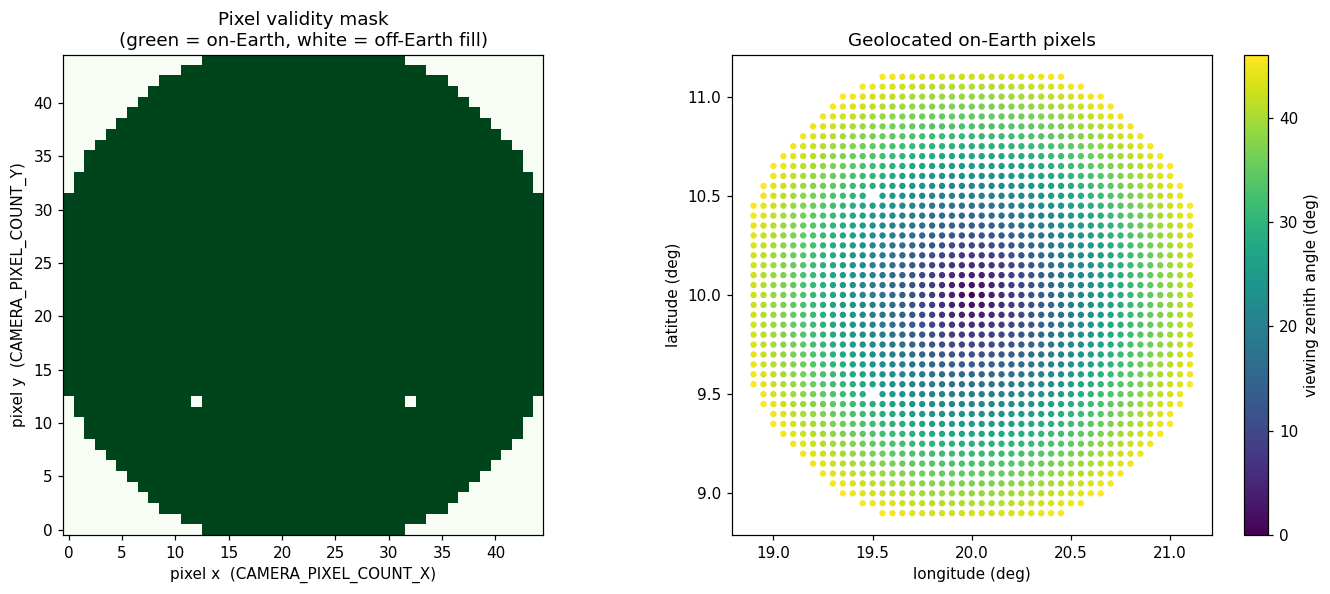

In [66]:
# Visualize the raw image two ways: as a pixel-grid validity mask, and as the
# geolocated cloud of on-Earth pixels colored by viewing zenith angle.
fig, (ax0, ax1) = plt.subplots(1, 2, figsize=(13, 5.5))

# Left: validity in PIXEL space. .T + origin='lower' puts x (latitude index) on the
# horizontal axis and y (longitude index) on the vertical, matching array [x, y].
ax0.imshow(valid.T, origin="lower", cmap="Greens", vmin=0, vmax=1)
ax0.set_title("Pixel validity mask\n(green = on-Earth, white = off-Earth fill)")
ax0.set_xlabel("pixel x  (CAMERA_PIXEL_COUNT_X)")
ax0.set_ylabel("pixel y  (CAMERA_PIXEL_COUNT_Y)")

# Right: the same pixels in GEOGRAPHIC space, colored by VZA. Off-Earth pixels are
# masked out so only the real ground samples appear.
lat_v = np.where(valid, lat2d, np.nan)
lon_v = np.where(valid, lon2d, np.nan)
sc = ax1.scatter(lon_v, lat_v, c=np.where(valid, vza2d, np.nan), s=10, cmap="viridis")
fig.colorbar(sc, ax=ax1, label="viewing zenith angle (deg)")
ax1.set_title("Geolocated on-Earth pixels")
ax1.set_xlabel("longitude (deg)")
ax1.set_ylabel("latitude (deg)")
ax1.set_aspect("equal")
fig.tight_layout()
plt.show()

## 2. How big is a pseudo-footprint? FOV → target diameter → block size

We want each block's *ground* extent to approximate a real radiometer footprint. That
requires two numbers:

**1. The target footprint diameter on the ground.** Rather than hard-code a value, the
module *derives* it from single sources of truth already in the codebase — the
radiometer FOV half-angle (`LIBERA_FOV_HALFANGLE_DEG = 1.0°`) and the nominal orbit
altitude (`NOMINAL_ALTITUDE_KM = 835 km`). At nadir a footprint's ground **radius** is
`altitude · tan(half-angle)`, so the **diameter** is:

$$D = 2 \cdot \text{altitude} \cdot \tan(\text{half-angle}) \approx 29\ \text{km.}$$

Deriving it this way means a change to the FOV or the nominal altitude propagates
automatically. (See the `TARGET_FOOTPRINT_DIAMETER_KM` definition and
`TODO[LIBSDC-794]`: read the true footprint size from mission config once available.)

**2. The ground-sampling distance (GSD)** — how far apart adjacent pixels are on the
ground, in km. `_estimate_ground_sampling_distance_km` measures the *geodesic* distance
(via a WGS84 [`pyproj.Geod`](https://pyproj4.github.io/pyproj/stable/api/geod.html)
`inv`) between the center pixel and its neighbors in each grid direction, sampling
near the image center where the grid is most likely populated and least distorted.

The block side is then simply `round(target_diameter / GSD)`, clamped to ≥ 1 pixel so a
very coarse image still yields single-pixel footprints instead of an empty result.

In [67]:
gsd_km = seg._estimate_ground_sampling_distance_km(lat2d, lon2d)
block = seg._block_size_pixels(gsd_km)
ground_radius_km = NOMINAL_ALTITUDE_KM * np.tan(np.radians(LIBERA_FOV_HALFANGLE_DEG))

print(f"FOV half-angle          : {LIBERA_FOV_HALFANGLE_DEG:.2f} deg")
print(f"nominal altitude        : {NOMINAL_ALTITUDE_KM:.0f} km")
print(f"-> ground radius         : {ground_radius_km:.2f} km")
print(f"-> target diameter (D)   : {TARGET_FOOTPRINT_DIAMETER_KM:.2f} km")
print(f"estimated GSD            : {gsd_km:.2f} km / pixel")
print(f"-> block side            : round(D / GSD) = {block} pixels")

FOV half-angle          : 1.00 deg
nominal altitude        : 835 km
-> ground radius         : 14.57 km
-> target diameter (D)   : 29.15 km
estimated GSD            : 5.51 km / pixel
-> block side            : round(D / GSD) = 5 pixels


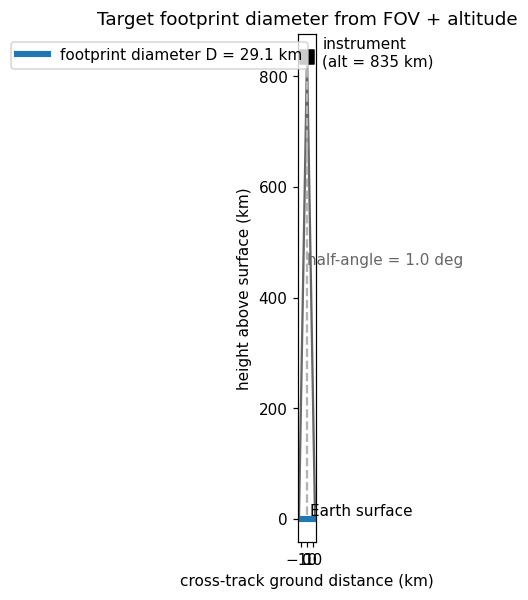

In [68]:
# A schematic of the D = 2 * altitude * tan(half-angle) geometry: the instrument at the
# top of an isoceles triangle whose base is the footprint on the ground. This is the
# 'why' behind the target-diameter constant.
fig, ax = plt.subplots(figsize=(6.5, 6))
sat = (0.0, NOMINAL_ALTITUDE_KM)
left = (-ground_radius_km, 0.0)
right = (ground_radius_km, 0.0)

# The two FOV edge rays and the ground footprint.
ax.plot([sat[0], left[0]], [sat[1], left[1]], color="0.4")
ax.plot([sat[0], right[0]], [sat[1], right[1]], color="0.4")
ax.plot([sat[0], 0.0], [sat[1], 0.0], color="0.7", ls="--")  # nadir / boresight
ax.plot(
    [left[0], right[0]],
    [0, 0],
    color=FLAG_COLORS["clean"],
    lw=4,
    label=f"footprint diameter D = {TARGET_FOOTPRINT_DIAMETER_KM:.1f} km",
)

ax.scatter(*sat, marker="s", s=90, color="k", zorder=5)
ax.annotate("instrument\n(alt = 835 km)", sat, textcoords="offset points", xytext=(10, -6))
ax.annotate("half-angle = 1.0 deg", (0, NOMINAL_ALTITUDE_KM * 0.55), color="0.4")
ax.annotate("Earth surface", (right[0] * 0.35, 6))

ax.set_title("Target footprint diameter from FOV + altitude")
ax.set_xlabel("cross-track ground distance (km)")
ax.set_ylabel("height above surface (km)")
ax.legend(loc="upper right")
ax.set_aspect("equal")
plt.show()

## 3. Tiling the image into blocks

With a block side in hand, `_iter_blocks` tiles the `(nx, ny)` pixel grid into
contiguous `block × block` slices in row-major order. Blocks along the right/bottom
edges that don't divide evenly are simply **smaller** (a partial block), so no pixel is
ever dropped just because the image size isn't a multiple of the block side.

`_corner_indices` returns the four corner pixels of a block — deduplicated, so a
1-pixel-wide edge block doesn't report the same corner twice. Those corners (and *only*
those corners) define the bounding box in the next section.

81 blocks of up to 5 x 5 pixels (ceil(45/5) x ceil(45/5) = 9 x 9)


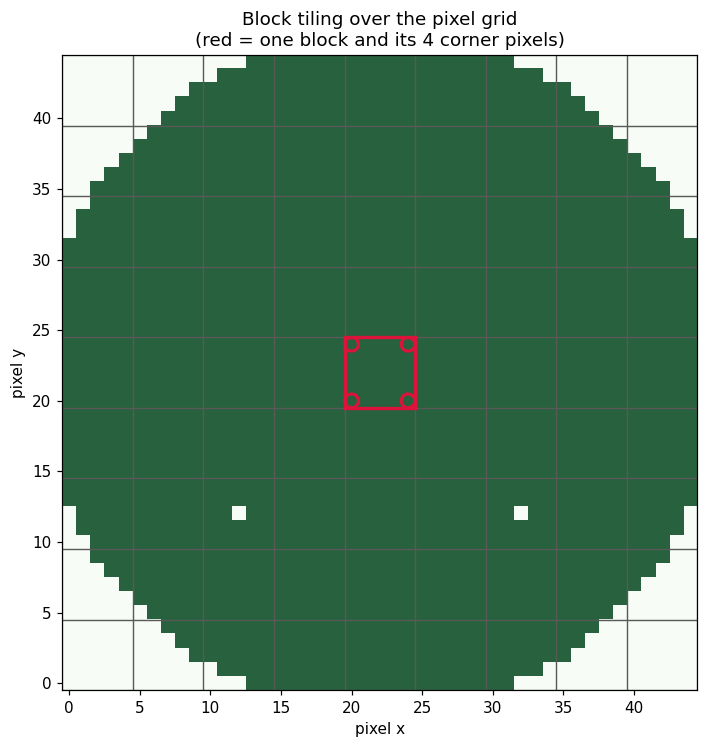

In [69]:
blocks = seg._iter_blocks(nx, ny, block)
print(
    f"{len(blocks)} blocks of up to {block} x {block} pixels "
    f"(ceil({nx}/{block}) x ceil({ny}/{block}) = {-(-nx // block)} x {-(-ny // block)})"
)

# Draw the tiling over the validity mask, and highlight one interior block's corners.
fig, ax = plt.subplots(figsize=(7.5, 7.5))
ax.imshow(valid.T, origin="lower", cmap="Greens", vmin=0, vmax=1, alpha=0.85)
for sx, sy in blocks:
    # Rectangle in pixel space; the -0.5 offset aligns the edge with the pixel border.
    ax.add_patch(
        Rectangle(
            (sx.start - 0.5, sy.start - 0.5), sx.stop - sx.start, sy.stop - sy.start, fill=False, ec="0.35", lw=0.8
        )
    )

# Highlight the center-most block and mark its four corner pixels.
hl_sx, hl_sy = blocks[len(blocks) // 2]
for cxi, cyi in seg._corner_indices(hl_sx, hl_sy):
    ax.scatter(cxi, cyi, s=80, facecolor="none", edgecolor="crimson", lw=2, zorder=5)
ax.add_patch(
    Rectangle(
        (hl_sx.start - 0.5, hl_sy.start - 0.5),
        hl_sx.stop - hl_sx.start,
        hl_sy.stop - hl_sy.start,
        fill=False,
        ec="crimson",
        lw=2.2,
    )
)

ax.set_title("Block tiling over the pixel grid\n(red = one block and its 4 corner pixels)")
ax.set_xlabel("pixel x")
ax.set_ylabel("pixel y")
plt.show()

## 4. One block → corner bounding box + center pixel

For a single block the module does two things:

1. **Bounding box from the corners only.** Because every camera pixel is already
   geolocated, the box that encloses the block is just the lat/lon envelope of its
   *corner* pixels — the interior can't stick out past them on a regular grid. The
   corners are handed to `bounding_box_from_points`, the **same** assembler the
   radiometer PSF path uses, which adds pole-enclosure and dateline handling. (Camera
   corner boxes are never limb-truncated — the pixels are already on the surface — so
   `truncated=False`.)
2. **The center pixel** is chosen as the footprint's boresight stand-in by
   `_select_center_pixel` (Section 5 covers the fill-substitution case). Its lat, lon,
   altitude and angles become the pseudo-footprint's scalar geometry.

Below we take a clean interior block and draw its pixels, its four corners, the center
pixel, and the resulting bounding box in geographic space.

center pixel : (22, 22) substituted: False
bounding box : BoundingBox(lat=[9.9, 10.1], lon=[19.9, 20.1], wraps_dateline=False, is_polar=False, truncated=False)


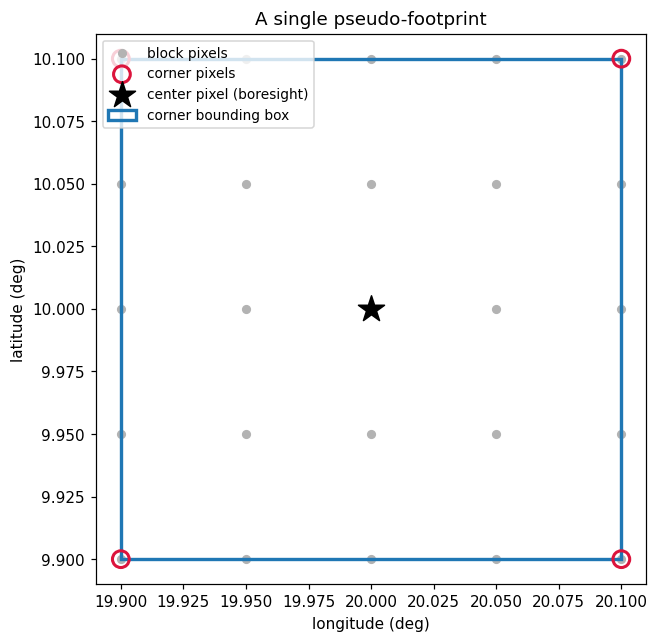

In [70]:
# Use the same highlighted block from Section 3.
sx, sy = hl_sx, hl_sy
corner_ij = seg._corner_indices(sx, sy)
center_ix, center_iy, substituted = seg._select_center_pixel(sx, sy, valid)

# Collect the valid corner lat/lons and assemble the box exactly as _build_footprint does.
corner_lats = [float(lat2d[i, j]) for i, j in corner_ij if valid[i, j]]
corner_lons = [float(lon2d[i, j]) for i, j in corner_ij if valid[i, j]]
bbox = bounding_box_from_points(
    float(lat2d[center_ix, center_iy]),
    float(lon2d[center_ix, center_iy]),
    corner_lats,
    corner_lons,
    truncated=False,
)
print("center pixel :", (center_ix, center_iy), "substituted:", substituted)
print("bounding box :", bbox)

fig, ax = plt.subplots(figsize=(6.5, 6.5))
# All pixels in the block (light dots), the four corners (red rings), the center (star),
# and the corner-derived bounding box (blue rectangle).
blk_lat = lat2d[sx, sy]
blk_lon = lon2d[sx, sy]
ax.scatter(blk_lon, blk_lat, s=25, color="0.7", label="block pixels")
ax.scatter(
    corner_lons, corner_lats, s=120, facecolor="none", edgecolor="crimson", lw=2, label="corner pixels", zorder=5
)
ax.scatter(
    lon2d[center_ix, center_iy],
    lat2d[center_ix, center_iy],
    marker="*",
    s=320,
    color="k",
    label="center pixel (boresight)",
    zorder=6,
)
ax.add_patch(
    Rectangle(
        (bbox.lon_min, bbox.lat_min),
        bbox.lon_max - bbox.lon_min,
        bbox.lat_max - bbox.lat_min,
        fill=False,
        ec=FLAG_COLORS["clean"],
        lw=2.2,
        label="corner bounding box",
    )
)
ax.set_title("A single pseudo-footprint")
ax.set_xlabel("longitude (deg)")
ax.set_ylabel("latitude (deg)")
ax.set_aspect("equal")
ax.legend(loc="upper left", fontsize=9)
plt.show()

### A square pixel block is *not* a square lat/lon box

Blocks are square in **pixel** space (`block × block` pixels, Section 3), but their
lat/lon bounding box generally is **not** square. Two effects distort it:

1. **Viewing-geometry / PSF stretch.** A camera pixel's *ground* footprint grows toward
   the limb. For a rectilinear (pinhole) view the ground offset is
   `altitude · tan(view-angle)`, and because `d(tanθ)/dθ = sec²θ`, equal pixel steps
   cover **more ground** at large view angles — and they do so **anisotropically**: the
   *radial* (toward-limb) direction stretches by ~`sec²(VZA)` while the *tangential*
   direction barely changes. This is the same effect
   [`geometry.py`](../libera_utils/footprint_matching/geometry.py) projects for the
   radiometer, where the box area grows sharply with VZA (see `geometry_demo`).
2. **Longitude convergence.** A degree of longitude shrinks as `cos(latitude)`, so even
   a physically square ground patch spans more degrees of longitude than latitude.

The main-demo image used a regular lat/lon grid, which hides effect (1). Here we instead
geolocate pixels with a simple perspective camera model and place the **same square
block** near nadir and near the limb, then build each box with the module's real
`bounding_box_from_points` and measure its ground extent with a WGS84 geodesic.

nadir: VZA=   0 deg  ground N-S= 130.6 km  E-W= 131.7 km  aspect(N-S/E-W)=0.99  (dlat=1.18, dlon=1.20)
limb : VZA=  45 deg  ground N-S= 263.0 km  E-W= 128.1 km  aspect(N-S/E-W)=2.05  (dlat=2.38, dlon=1.20)


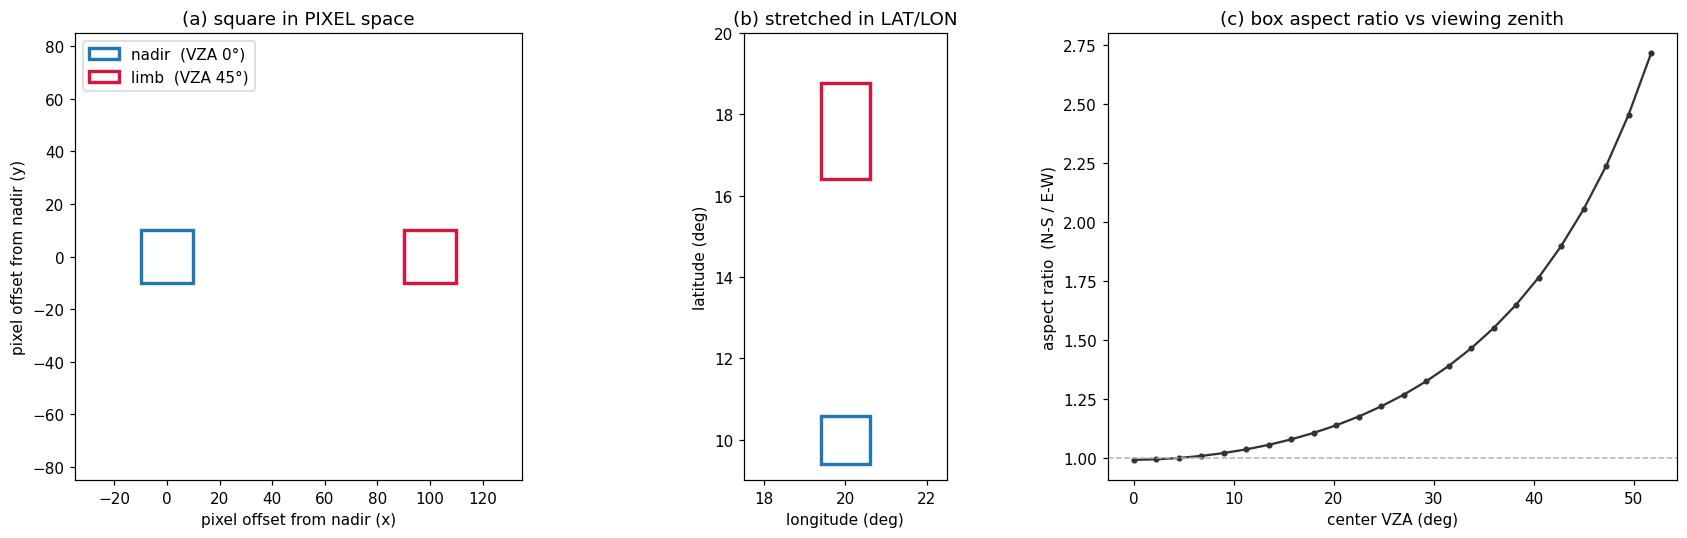

In [71]:
from pyproj import Geod

# WGS84 geodesic, used to measure a box's true ground extent -- the same ellipsoid the
# module uses (bounding_box_from_points / camera_segmentation both go through pyproj).
_GEOD = Geod(ellps="WGS84")

# --- A simple rectilinear (pinhole) camera geolocation model --------------------------
IFOV_DEG = 0.45           # angular size of one pixel (instantaneous FOV)
LAT0, LON0 = 10.0, 20.0   # sub-satellite (nadir) ground point
BLOCK_PX = 20             # a square block: BLOCK_PX x BLOCK_PX pixels


def pixel_to_latlon(dx, dy):
    """Map a pixel offset from nadir ``(dx, dy)`` to ``(lat, lon, VZA)``.

    Each pixel offset becomes a view angle ``offset * IFOV``; the look ray meets the
    ground ``altitude * tan(angle)`` from the sub-satellite point (flat-Earth
    approximation, to isolate the viewing-geometry stretch from Earth curvature). The
    ``tan`` is the whole point: its spacing grows like ``sec^2`` toward the edges, so a
    uniform pixel grid lands on a *non-uniform* ground grid -- the PSF stretch.
    """
    tx = np.tan(np.radians(dx * IFOV_DEG))
    ty = np.tan(np.radians(dy * IFOV_DEG))
    north_km = NOMINAL_ALTITUDE_KM * tx
    east_km = NOMINAL_ALTITUDE_KM * ty
    lat = LAT0 + north_km / 111.32                                   # 1 deg lat ~ 111.32 km
    lon = LON0 + east_km / (111.32 * np.cos(np.radians(LAT0)))       # lon shrinks with cos(lat)
    vza = np.degrees(np.arccos(1.0 / np.sqrt(1.0 + tx**2 + ty**2)))  # off-nadir view angle
    return lat, lon, vza


def block_box(center_dx, center_dy):
    """Corner bounding box (via the module's assembler) for a square block at an offset."""
    half = BLOCK_PX / 2
    corner_offsets = [(center_dx - half, center_dy - half), (center_dx - half, center_dy + half),
                      (center_dx + half, center_dy - half), (center_dx + half, center_dy + half)]
    lats, lons, _ = zip(*[pixel_to_latlon(dx, dy) for dx, dy in corner_offsets])
    clat, clon, cvza = pixel_to_latlon(center_dx, center_dy)
    # Exactly the call camera_segmentation makes: build the box from the 4 valid corners.
    bb = bounding_box_from_points(clat, clon, list(lats), list(lons), truncated=False)
    return bb, cvza


def box_ground_dims_km(bb):
    """(north-south, east-west) ground extent of a box in km, measured geodesically."""
    ns = _GEOD.inv(bb.lon_min, bb.lat_min, bb.lon_min, bb.lat_max)[2] / 1000.0
    ew = _GEOD.inv(bb.lon_min, bb.lat_min, bb.lon_max, bb.lat_min)[2] / 1000.0
    return ns, ew


# The SAME square block, near nadir and ~100 pixels off-nadir (toward the limb).
nadir_bb, nadir_vza = block_box(0, 0)
limb_bb, limb_vza = block_box(100, 0)
for name, bb, vza in [("nadir", nadir_bb, nadir_vza), ("limb ", limb_bb, limb_vza)]:
    ns, ew = box_ground_dims_km(bb)
    print(f"{name}: VZA={vza:4.0f} deg  ground N-S={ns:6.1f} km  E-W={ew:6.1f} km  "
          f"aspect(N-S/E-W)={ns / ew:4.2f}  (dlat={bb.lat_max - bb.lat_min:.2f}, dlon={bb.lon_max - bb.lon_min:.2f})")

# Sweep the block from nadir to the limb to trace how the aspect ratio grows with VZA.
offsets = np.arange(0, 116, 5)
sweep = [(*box_ground_dims_km(block_box(o, 0)[0]), block_box(o, 0)[1]) for o in offsets]
ns_km, ew_km, vzas = map(np.array, zip(*sweep))

fig, (axp, axg, axs) = plt.subplots(1, 3, figsize=(16, 5))

# (a) PIXEL space: the two blocks are identical squares.
for (cdx, cdy), color, label in [((0, 0), "tab:blue", f"nadir  (VZA {nadir_vza:.0f}°)"),
                                 ((100, 0), "crimson", f"limb  (VZA {limb_vza:.0f}°)")]:
    axp.add_patch(Rectangle((cdx - BLOCK_PX / 2, cdy - BLOCK_PX / 2), BLOCK_PX, BLOCK_PX,
                            fill=False, ec=color, lw=2.2, label=label))
axp.set_title("(a) square in PIXEL space")
axp.set_xlabel("pixel offset from nadir (x)")
axp.set_ylabel("pixel offset from nadir (y)")
axp.set_xlim(-35, 135); axp.set_ylim(-85, 85); axp.set_aspect("equal"); axp.legend(loc="upper left")

# (b) LAT/LON space: the limb box is bigger and stretched north-south (radially).
for bb, color in [(nadir_bb, "tab:blue"), (limb_bb, "crimson")]:
    axg.add_patch(Rectangle((bb.lon_min, bb.lat_min), bb.lon_max - bb.lon_min,
                            bb.lat_max - bb.lat_min, fill=False, ec=color, lw=2.2))
axg.set_title("(b) stretched in LAT/LON")
axg.set_xlabel("longitude (deg)")
axg.set_ylabel("latitude (deg)")
axg.set_xlim(17.5, 22.5); axg.set_ylim(9, 20); axg.set_aspect("equal")

# (c) The stretch is a function of viewing geometry.
axs.plot(vzas, ns_km / ew_km, "-o", ms=3, color="0.2")
axs.axhline(1.0, color="0.7", ls="--", lw=1)
axs.set_title("(c) box aspect ratio vs viewing zenith")
axs.set_xlabel("center VZA (deg)")
axs.set_ylabel("aspect ratio  (N-S / E-W)")
fig.tight_layout()
plt.show()

## 5. The off-Earth policy and quality flags

Because the camera sees past the limb, a block's corners or center can be fill even
when the block straddles the Earth's edge. The module applies a fixed policy, recording
the outcome in `CameraFootprintQualityFlag` (an
[`IntFlag`](https://docs.python.org/3/library/enum.html#enum.IntFlag), so flags OR
together and `0` means "clean"):

| Situation | Action | Flag |
| --- | --- | --- |
| **all four corners** fill | drop the block — there is effectively no footprint | *(no record)* |
| **some (not all) corners** fill | shrink the box to the valid corners | `PARTIAL_COVERAGE` |
| **center pixel** fill | substitute the nearest valid pixel as boresight | `CENTER_PIXEL_SUBSTITUTED` |

The map below colors every block by its outcome. Notice how the **partial** blocks
trace the limb (some corners hang off the Earth), the **dropped** blocks sit fully in
the off-Earth corners, and the **substituted** blocks include our two punched-in bad
pixels *plus* any edge block whose geometric center happens to fall off-Earth.

block outcomes: {'dropped': 4, 'clean': 55, 'partial': 20, 'substituted': 2}


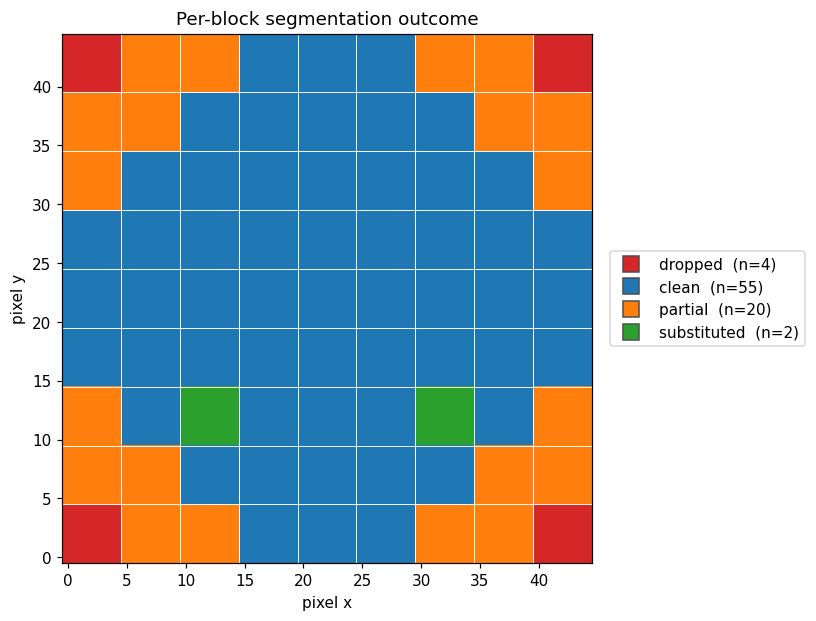

In [72]:
# Segment just this one image via the internal per-image routine so we can line the
# resulting footprints back up with the blocks that produced them.
image_footprints = seg._segment_image(
    ds[seg.CAMERA_TIME_NAME].values[0],
    lat2d,
    lon2d,
    ds[seg.ALTITUDE_NAME].values[0],
    ds[seg.SOLAR_ZENITH_NAME].values[0],
    ds[seg.VIEWING_ZENITH_NAME].values[0],
    ds[seg.RELATIVE_AZIMUTH_NAME].values[0],
)
# Index produced footprints by their block's top-left corner for lookup.
produced = {(f.slice_x.start, f.slice_y.start): f for f in image_footprints}

# Outcome code per pixel: 0 dropped, 1 clean, 2 partial, 3 substituted.
CODE = {"dropped": 0, "clean": 1, "partial": 2, "substituted": 3}
outcome = np.full((nx, ny), CODE["dropped"], dtype=int)
counts = {k: 0 for k in CODE}
for sx, sy in blocks:
    f = produced.get((sx.start, sy.start))
    if f is None:
        key = "dropped"
    elif f.q_flags & CameraFootprintQualityFlag.PARTIAL_COVERAGE:
        key = "partial"
    elif f.q_flags & CameraFootprintQualityFlag.CENTER_PIXEL_SUBSTITUTED:
        key = "substituted"
    else:
        key = "clean"
    outcome[sx, sy] = CODE[key]
    counts[key] += 1
print("block outcomes:", counts)

# Discrete colormap keyed to the outcome codes, with a matching legend.
order = ["dropped", "clean", "partial", "substituted"]
cmap = ListedColormap([FLAG_COLORS[k] for k in order])
norm = BoundaryNorm([-0.5, 0.5, 1.5, 2.5, 3.5], cmap.N)

fig, ax = plt.subplots(figsize=(7.5, 7.5))
ax.imshow(outcome.T, origin="lower", cmap=cmap, norm=norm)
for sx, sy in blocks:  # thin block borders for context
    ax.add_patch(
        Rectangle((sx.start - 0.5, sy.start - 0.5), sx.stop - sx.start, sy.stop - sy.start, fill=False, ec="w", lw=0.5)
    )
ax.set_title("Per-block segmentation outcome")
ax.set_xlabel("pixel x")
ax.set_ylabel("pixel y")
ax.legend(
    handles=[
        Line2D(
            [0],
            [0],
            marker="s",
            ls="",
            markersize=11,
            markerfacecolor=FLAG_COLORS[k],
            markeredgecolor="0.3",
            label=f"{k}  (n={counts[k]})",
        )
        for k in order
    ],
    loc="center left",
    bbox_to_anchor=(1.02, 0.5),
)
fig.tight_layout()
plt.show()

## 6. The public entry point: `segment_l1b_camera`

Everything above is wrapped by a single public function. `segment_l1b_camera(dataset)`
iterates every image on the `CAMERA_TIME` axis, segments each into pseudo-footprints,
and returns them as one flat list of `PseudoFootprint` dataclasses — in the exact
order they will be written to the FMATCH-CAM-CAMTIME product.

Each `PseudoFootprint` carries its source `time`, the pixel-block provenance
(`slice_x`/`slice_y`, `center_ix`/`center_iy`), the reduced center-pixel geometry
(lat/lon/alt + angles), the corner `bbox`, and its `q_flags`.

> **On `CAMERA_TIME` uniqueness:** because one image yields *many* footprints, all
> footprints from an image share that image's timestamp. The product therefore has
> repeated `CAMERA_TIME` values (unlike a strictly increasing radiometer timeline) —
> the time identifies the *source image*, not a unique footprint. We confirm this below.

In [73]:
footprints = segment_l1b_camera(ds)
print(f"{len(footprints)} pseudo-footprints from {ds.sizes[seg.CAMERA_TIME_NAME]} image(s)")

# All footprints from our single image share its one timestamp (the note above).
unique_times = np.unique([f.time for f in footprints])
print(f"unique CAMERA_TIME values among footprints: {unique_times.size}")

f0 = footprints[0]
print("\nexample footprint:")
print(f"  time      : {f0.time}")
print(f"  block     : x={f0.slice_x}, y={f0.slice_y}")
print(f"  center px : ({f0.center_ix}, {f0.center_iy})")
print(f"  lat/lon   : ({f0.latitude:.3f}, {f0.longitude:.3f})")
print(f"  sza/vza/raa: {f0.solar_zenith_angle:.1f} / {f0.viewing_zenith_angle:.1f} / {f0.relative_azimuth_angle:.1f}")
print(f"  bbox      : {f0.bbox}")
print(f"  q_flags   : {f0.q_flags!r}")

77 pseudo-footprints from 1 image(s)
unique CAMERA_TIME values among footprints: 1

example footprint:
  time      : 2028-02-12T03:39:45.000000000
  block     : x=slice(0, 5, None), y=slice(5, 10, None)
  center px : (3, 8)
  lat/lon   : (9.050, 19.300)
  sza/vza/raa: 49.2 / 45.5 / 120.0
  bbox      : BoundingBox(lat=[9.1, 9.1], lon=[19.35, 19.35], wraps_dateline=False, is_polar=False, truncated=False)
  q_flags   : <CameraFootprintQualityFlag.PARTIAL_COVERAGE|CENTER_PIXEL_SUBSTITUTED: 3>


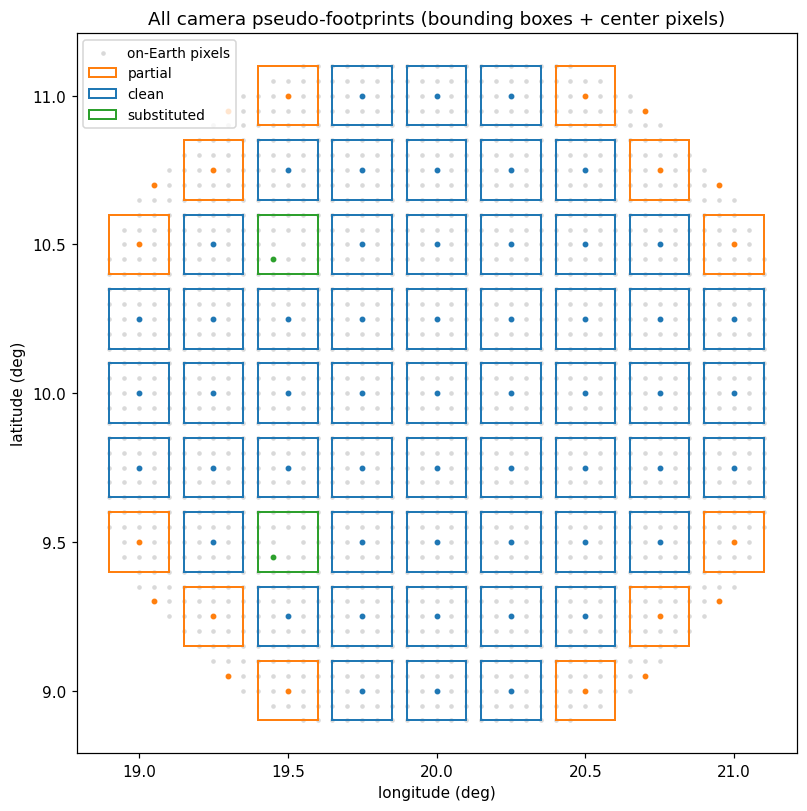

In [74]:
# The payoff: every pseudo-footprint's bounding box drawn over the on-Earth pixels,
# colored by its quality flag. This is the set of 'radiometer-like' footprints the
# rest of the FMATCH pipeline will consume.
def footprint_kind(f):
    if f.q_flags & CameraFootprintQualityFlag.PARTIAL_COVERAGE:
        return "partial"
    if f.q_flags & CameraFootprintQualityFlag.CENTER_PIXEL_SUBSTITUTED:
        return "substituted"
    return "clean"


fig, ax = plt.subplots(figsize=(8.5, 8.5))
ax.scatter(lon_v, lat_v, s=4, color="0.85", label="on-Earth pixels")
seen = set()
for f in footprints:
    kind = footprint_kind(f)
    bb = f.bbox
    ax.add_patch(
        Rectangle(
            (bb.lon_min, bb.lat_min),
            bb.lon_max - bb.lon_min,
            bb.lat_max - bb.lat_min,
            fill=False,
            ec=FLAG_COLORS[kind],
            lw=1.3,
            label=kind if kind not in seen else None,
        )
    )
    ax.scatter(f.longitude, f.latitude, s=8, color=FLAG_COLORS[kind])
    seen.add(kind)
ax.set_title("All camera pseudo-footprints (bounding boxes + center pixels)")
ax.set_xlabel("longitude (deg)")
ax.set_ylabel("latitude (deg)")
ax.set_aspect("equal")
ax.legend(loc="upper left", fontsize=9)
plt.show()

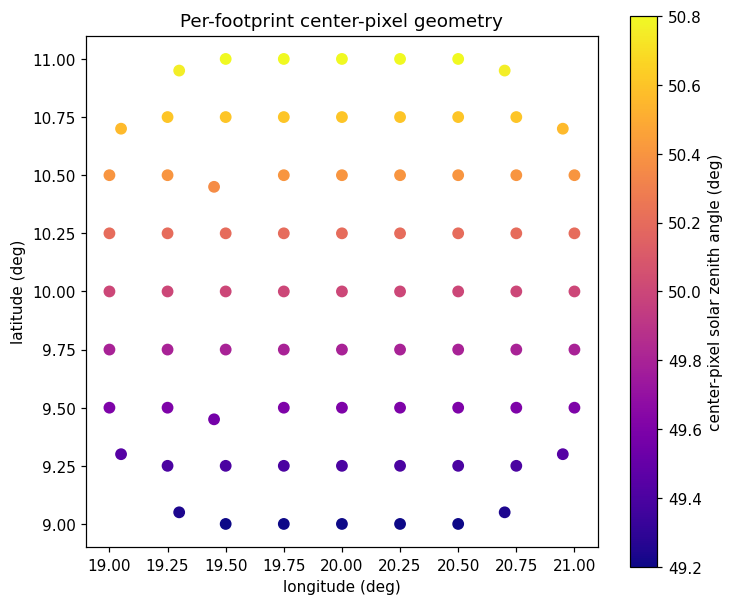

In [75]:
# The per-footprint scalar geometry is just the center-pixel value. Colouring the
# footprint centers by solar zenith angle shows the smooth field the reduction keeps.
fig, ax = plt.subplots(figsize=(7.5, 6.5))
sc = ax.scatter(
    [f.longitude for f in footprints],
    [f.latitude for f in footprints],
    c=[f.solar_zenith_angle for f in footprints],
    s=45,
    cmap="plasma",
)
fig.colorbar(sc, ax=ax, label="center-pixel solar zenith angle (deg)")
ax.set_title("Per-footprint center-pixel geometry")
ax.set_xlabel("longitude (deg)")
ax.set_ylabel("latitude (deg)")
ax.set_aspect("equal")
plt.show()

## 6b. Resizing pseudo-footprints for analysis (not production)

Production always sizes blocks from the FOV-derived `TARGET_FOOTPRINT_DIAMETER_KM`
(~29 km, Section 2). 

Because the segmenter derives its block side from that single module-level constant
(`_block_size_pixels` reads `TARGET_FOOTPRINT_DIAMETER_KM` at call time), we can grow
every footprint's bounding box simply by *temporarily* scaling it — no production code
changes. The context manager below restores the original value afterwards, so the rest
of the notebook is unaffected. As the footprints grow, they get **bigger and fewer**.

> **Not a production path.** The scaled diameter is an experimental knob; the shipped
> FMATCH-CAM-CAMTIME product always uses the FOV-derived size.

scale x  1  ->  target diameter  29.1 km,   77 pseudo-footprints
scale x  2  ->  target diameter  58.3 km,   20 pseudo-footprints
scale x  4  ->  target diameter 116.6 km,    8 pseudo-footprints
Production constant correctly restored.


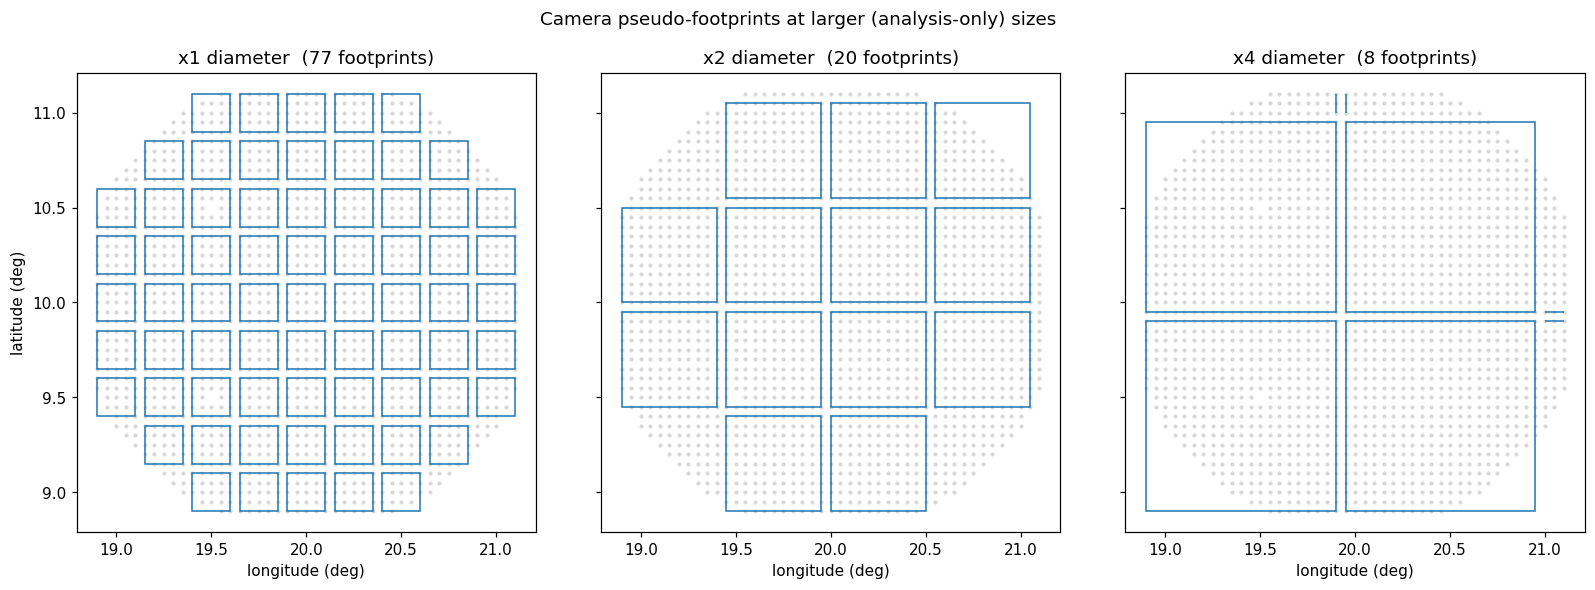

In [76]:
import contextlib


@contextlib.contextmanager
def scaled_footprint_diameter(scale: float):
    """Temporarily scale the target pseudo-footprint diameter by ``scale`` (NON-PRODUCTION).

    ``camera_segmentation`` sizes every pixel block from the module-level constant
    ``TARGET_FOOTPRINT_DIAMETER_KM`` (see ``_block_size_pixels``), which is looked up at
    call time. Overriding it here therefore grows *every* pseudo-footprint's block --
    and hence its corner bounding box -- by ``scale``, with no change to production code.
    The original value is always restored on exit so later cells behave normally.
    """
    original = seg.TARGET_FOOTPRINT_DIAMETER_KM
    seg.TARGET_FOOTPRINT_DIAMETER_KM = original * scale
    try:
        yield seg.TARGET_FOOTPRINT_DIAMETER_KM
    finally:
        seg.TARGET_FOOTPRINT_DIAMETER_KM = original


# Segment the same image at the nominal size and at 2x / 4x that size.
scales = [1.0, 2.0, 4.0]
scaled_results = {}
for s in scales:
    with scaled_footprint_diameter(s) as diameter_km:
        scaled_results[s] = segment_l1b_camera(ds)
    print(
        f"scale x{s:>3.0f}  ->  target diameter {diameter_km:5.1f} km,  {len(scaled_results[s]):3d} pseudo-footprints"
    )

# Confirm the production constant was restored (so Section 7 uses the real size).
if seg.TARGET_FOOTPRINT_DIAMETER_KM == TARGET_FOOTPRINT_DIAMETER_KM:
    print("Production constant correctly restored.")
else:
    print("ERROR: Production constant not restored.")

# Side-by-side: same pixels, progressively larger (and fewer) bounding boxes.
fig, axes = plt.subplots(1, len(scales), figsize=(5 * len(scales), 5), sharex=True, sharey=True)
for ax, s in zip(axes, scales):
    ax.scatter(lon_v, lat_v, s=3, color="0.85")
    for f in scaled_results[s]:
        bb = f.bbox
        ax.add_patch(
            Rectangle(
                (bb.lon_min, bb.lat_min),
                bb.lon_max - bb.lon_min,
                bb.lat_max - bb.lat_min,
                fill=False,
                ec=FLAG_COLORS["clean"],
                lw=1.0,
            )
        )
    ax.set_title(f"x{s:.0f} diameter  ({len(scaled_results[s])} footprints)")
    ax.set_xlabel("longitude (deg)")
    ax.set_aspect("equal")
axes[0].set_ylabel("latitude (deg)")
fig.suptitle("Camera pseudo-footprints at larger (analysis-only) sizes", y=1.02)
fig.tight_layout()
plt.show()

### Fetching external data for the larger bounding box

A pseudo-footprint's bounding box is the *query region* the FMATCH pipeline uses to
pull ancillary data. Each reader in
[`libera_utils.footprint_matching.readers`](../libera_utils/footprint_matching/readers/)
slices its gridded source to a `BoundingBox` (its `_load_spatial_region(bbox)` hook; in
production the `TileManager` wraps this with 2° tiling and caching). A **larger**
analysis footprint therefore fetches a **larger area** — more grid cells, over which an
algorithm could aggregate or compute statistics.

We demonstrate this with the real
[`ERA5Reader`](../libera_utils/footprint_matching/readers/era5.py) (10 m winds). There
is no ERA5 file in the repo, so we synthesise a small, spatially varying one covering
the scene (real files come from the
[Copernicus CDS](https://cds.climate.copernicus.eu/datasets/reanalysis-era5-single-levels)).
We then fetch ERA5 for the *same location* at the nominal (×1) and analysis (×4) sizes
and compare how much data each box pulls.

nominal (x1): bbox 9.90..10.10 lat, 19.90..20.10 lon  ->   1 ERA5 cell(s), mean wind 9.27 m/s
analysis (x4): bbox 9.95..10.95 lat, 19.95..20.95 lon  ->  16 ERA5 cell(s), mean wind 9.46 m/s


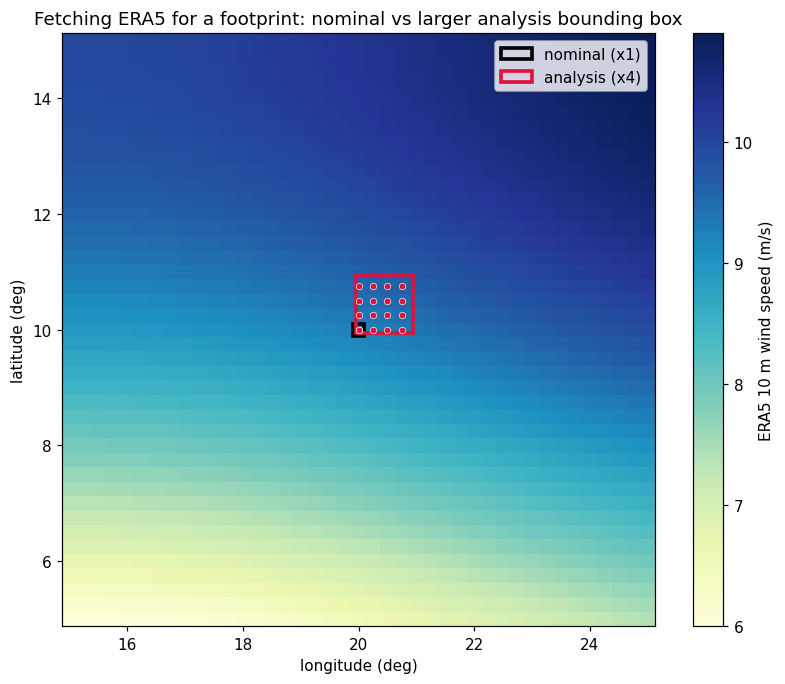

In [77]:
import tempfile
import pathlib
import xarray as xr

from libera_utils.footprint_matching.readers.era5 import ERA5Reader


def make_synthetic_era5(path, lat_range=(5.0, 15.0), lon_range=(15.0, 25.0), res_deg=0.25):
    """Write a small ERA5-style u10/v10 NetCDF over the scene (analysis stand-in).

    Mirrors the real CDS format: variables ``u10``/``v10`` on a regular lat/lon grid
    with the latitude coordinate in DESCENDING order (90 -> -90). We give the wind a
    smooth spatial pattern so the fetched region is visually interesting; a real file
    would be an actual reanalysis download.
    """
    lats = np.arange(lat_range[1], lat_range[0] - 1e-9, -res_deg)  # descending, like real ERA5
    lons = np.arange(lon_range[0], lon_range[1] + 1e-9, res_deg)
    LON, LAT = np.meshgrid(lons, lats)
    u10 = 8.0 * np.sin(np.radians(LAT * 6.0)) + 2.0
    v10 = 5.0 * np.cos(np.radians(LON * 6.0))
    xr.Dataset(
        {"u10": (("latitude", "longitude"), u10.astype("float32")),
         "v10": (("latitude", "longitude"), v10.astype("float32"))},
        coords={"latitude": lats, "longitude": lons},
    ).to_netcdf(path)


# Compare fetches for the SAME location at the nominal (x1) and analysis (x4) sizes.
lat_c = float(lat2d[nx // 2, ny // 2])
lon_c = float(lon2d[nx // 2, ny // 2])


def nearest_footprint(footprints, lat, lon):
    """The footprint whose center pixel is closest to (lat, lon)."""
    return min(footprints, key=lambda f: (f.latitude - lat) ** 2 + (f.longitude - lon) ** 2)


fetches = {}
with tempfile.TemporaryDirectory() as tmp:
    era5_path = pathlib.Path(tmp) / "synthetic_era5.nc"
    make_synthetic_era5(era5_path)

    # The real reader the pipeline uses. _load_spatial_region is its bounding-box hook;
    # the TileManager wraps it with tiling + caching in production, but for a single
    # footprint's area calling it directly is the clearest way to show the fetch.
    reader = ERA5Reader(era5_path)

    f_nom = nearest_footprint(scaled_results[1.0], lat_c, lon_c)
    f_big = nearest_footprint(scaled_results[4.0], lat_c, lon_c)
    for label, f, color in [("nominal (x1)", f_nom, "black"), ("analysis (x4)", f_big, "crimson")]:
        # data has shape (2, n_lat, n_lon) = [u10, v10] over the box; combine to a speed.
        data, la, lo = reader._load_spatial_region(f.bbox)
        speed = np.hypot(data[0], data[1])
        fetches[label] = (f, la, lo, speed, color)
        print(f"{label}: bbox {f.bbox.lat_min:.2f}..{f.bbox.lat_max:.2f} lat, "
              f"{f.bbox.lon_min:.2f}..{f.bbox.lon_max:.2f} lon  ->  "
              f"{speed.size:2d} ERA5 cell(s), mean wind {np.nanmean(speed):.2f} m/s")

    # The reader's own normalized (ascending-lat) grid, used as the map background.
    grid_data, grid_lats, grid_lons = reader._native_grid
    grid_speed = np.hypot(grid_data[0], grid_data[1])

# Background = full ERA5 field; overlays = the two boxes and the exact cells each pulled.
fig, ax = plt.subplots(figsize=(9, 7))
pcm = ax.pcolormesh(grid_lons, grid_lats, grid_speed, shading="auto", cmap="YlGnBu")
fig.colorbar(pcm, ax=ax, label="ERA5 10 m wind speed (m/s)")
for label, (f, la, lo, speed, color) in fetches.items():
    bb = f.bbox
    ax.add_patch(Rectangle((bb.lon_min, bb.lat_min), bb.lon_max - bb.lon_min,
                           bb.lat_max - bb.lat_min, fill=False, ec=color, lw=2.4, label=label))
    grid_lo, grid_la = np.meshgrid(lo, la)  # cell centers actually fetched for this box
    ax.scatter(grid_lo, grid_la, s=18, color=color, edgecolor="w", linewidth=0.4, zorder=5)
ax.set_title("Fetching ERA5 for a footprint: nominal vs larger analysis bounding box")
ax.set_xlabel("longitude (deg)")
ax.set_ylabel("latitude (deg)")
ax.legend(loc="upper right")
ax.set_aspect("equal")
plt.show()

## 7. Assembling the FMATCH-CAM-CAMTIME product

The pseudo-footprints feed straight into
[`libera_utils.footprint_matching.product`](../libera_utils/footprint_matching/product.py).
`_assemble_camtime_dataset` turns the footprint list into an `xarray.Dataset` that
conforms to the FMATCH-CAM-CAMTIME product definition, and `write_fmatch_product`
writes it to a standardized Libera NetCDF filename.

**What is real vs. placeholder:** the center-pixel geolocation/geometry, the
`psf_bbox_*` corner box, the pixel-block provenance, and the `q_flags` are computed
*for real* from the camera pixels. Every *aggregated* variable (ERA-5 / IGBP / NISE /
VIIRS columns, derived `sunglint_angle`, camera cloud fraction, `psf_coverage_fraction`)
is written as a **conformant placeholder** (NaN/fill) pending the PSF-aggregation and
derived-geometry engines (`TODO[LIBSDC-785]`). The file is therefore
shape-and-format-correct but only partially populated.

In [78]:
from libera_utils.footprint_matching.product import (
    _assemble_camtime_dataset,
    load_fmatch_definition,
    write_fmatch_product,
)
from libera_utils.footprint_matching.types import OperationalMode

definition = load_fmatch_definition(OperationalMode.CAM_CAMTIME)
product = _assemble_camtime_dataset(
    footprints,
    definition=definition,
    algorithm_version="0.1.0",
    input_files="synthetic_l1b_cam.nc",
)

# An empty list from check_dataset_conformance means the dataset fully satisfies the
# product definition (dtypes, dimensions, attributes).
issues = definition.check_dataset_conformance(product, strict=False)
print("conformance issues:", issues or "none")
print(f"records on CAMERA_TIME axis: {product.sizes[seg.CAMERA_TIME_NAME]}")

# Show a few real (segmentation-derived) columns next to a placeholder one.
print("\nlatitude (real)      :", np.round(product["latitude"].values[:5], 3))
print("q_flags  (real)      :", product["q_flags"].values[:5])
print("sunglint_angle (ph.) :", product["sunglint_angle"].values[:5])

conformance issues: none
records on CAMERA_TIME axis: 77

latitude (real)      : [9.05 9.   9.   9.   9.  ]
q_flags  (real)      : [3 1 0 0 0]
sunglint_angle (ph.) : [nan nan nan nan nan]


In [79]:
# Write a real NetCDF to a temporary directory to show the standardized filename the
# writer generates from the CAMERA_TIME span. (Local disk only -- no AWS/cloud I/O.)
import pathlib
import tempfile

with tempfile.TemporaryDirectory() as tmp:
    written = write_fmatch_product(
        OperationalMode.CAM_CAMTIME,
        footprints,
        pathlib.Path(tmp),
        algorithm_version="0.1.0",
        input_files="synthetic_l1b_cam.nc",
        strict=True,
    )
    print("wrote:", pathlib.Path(str(written.path)).name)

wrote: LIBERA_ANC_FMATCH-CAM-CAMTIME_V0-1-0_20280212T033945_20280212T033945_R26190202116.nc


## 8. (Optional) running on a real L1B camera file

The whole demo above runs on synthetic data so it is self-contained. If you have a real
L1B Daily Camera file (conforming to [`l1b_example/l1b_cam.yml`](../l1b_example/l1b_cam.yml)),
point `L1B_CAM_PATH` at it and the cell below will segment it exactly as
`run_fmatch_cam_camtime.py` does. The cell is skipped if the file is not present.

In [80]:
import pathlib

# Edit this to a real L1B Daily Camera NetCDF file to exercise the real path.
L1B_CAM_PATH = pathlib.Path("external_data/L1B/l1b_cam.nc")

if not L1B_CAM_PATH.exists():
    print(f"no L1B camera file at {L1B_CAM_PATH} -- skipping (this is expected)")
else:
    with xr.open_dataset(L1B_CAM_PATH) as real_ds:
        real_footprints = segment_l1b_camera(real_ds)
    print(f"segmented {len(real_footprints)} pseudo-footprints from {L1B_CAM_PATH.name}")

    fig, ax = plt.subplots(figsize=(9, 5))
    for f in real_footprints:
        bb = f.bbox
        ax.add_patch(
            Rectangle(
                (bb.lon_min, bb.lat_min),
                bb.lon_max - bb.lon_min,
                bb.lat_max - bb.lat_min,
                fill=False,
                ec=FLAG_COLORS["clean"],
                lw=0.6,
            )
        )
    ax.autoscale()
    ax.set_title(f"Pseudo-footprints from {L1B_CAM_PATH.name}")
    ax.set_xlabel("longitude (deg)")
    ax.set_ylabel("latitude (deg)")
    plt.show()

no L1B camera file at external_data/L1B/l1b_cam.nc -- skipping (this is expected)


## Summary

- The camera delivers *images* of geolocated pixels far finer than a radiometer
  footprint, so `camera_segmentation` groups pixels into radiometer-sized
  **pseudo-footprints** for the camera-timescale FMATCH products.
- A block's side is `round(target_diameter / GSD)`, where the **target diameter**
  (~29 km) is derived from the FOV half-angle and nominal altitude, and the **GSD** is
  measured geodesically near the image center.
- Each block reduces to a **corner-derived bounding box** (via the shared
  `bounding_box_from_points`) plus **center-pixel** scalar geometry.
- Off-Earth pixels are handled by an explicit policy: drop all-fill blocks, flag
  `PARTIAL_COVERAGE` when some corners are fill, and flag `CENTER_PIXEL_SUBSTITUTED`
  when the center is replaced by the nearest valid pixel.
- `segment_l1b_camera` is the one public entry point; its `PseudoFootprint` list feeds
  `product.write_fmatch_product` to build a conformant **FMATCH-CAM-CAMTIME** file.

### See also
- [`camera_segmentation.py`](../libera_utils/footprint_matching/camera_segmentation.py) — this module
- [`geometry.py`](../libera_utils/footprint_matching/geometry.py) & [`notebooks/geometry_demo.ipynb`](geometry_demo.ipynb) — the radiometer bounding-box path
- [`run_fmatch_cam_camtime.py`](../run_fmatch_cam_camtime.py) — the standalone driver